In [63]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import tqdm

In [64]:
# Set folder path to stored latents as obtained from the CT-CLIP model
folder = "Dino"
latent_file = "ripfrac_validation_set_ct_latents.npz"
latent_path = f"./latents/{latent_file}"
lable_file = "ribfrac-val-info.csv"
label_path = f"../data/rip_frac/ripfrac-val-info/{lable_file}"
latents_list = []
labels = []

Text(0.5, 0, 'Severity Score')

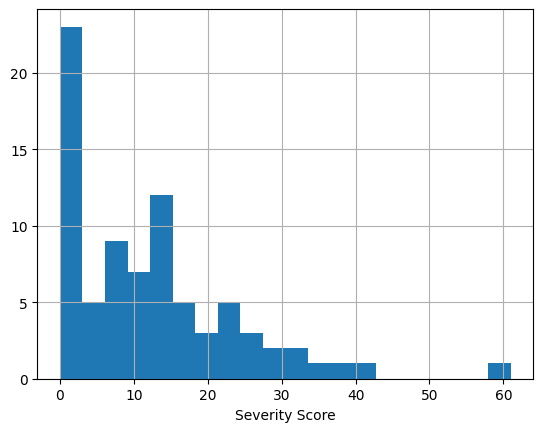

In [65]:
# Load the number of broken ribs per patient and turn into a severity score
weights = {
    0: 0,
    1: 3,
    2: 2,
    3: 1,
    4: 4,
    -1: 2
}
meta_data = pd.read_csv(label_path)
meta_data["fracture_weight"] = meta_data["label_code"].map(weights)
severity_score = meta_data.groupby("public_id")["fracture_weight"].sum().reset_index()
severity_score.rename(columns={"fracture_weight":"severity_score"}, inplace=True)
severity_score["severity_group"] = pd.cut(severity_score["severity_score"], bins=[0,20,40,80], labels=["0-20","21-40","41-80"])
severity_score["severity_score"].hist(bins=20)
plt.xlabel("Severity Score")

In [66]:
severity_score.shape

(80, 3)

In [67]:
severity_score.iloc[4]["severity_score"].item()

13

In [68]:
# transform latents to 2D data frame
latents = np.load(latent_path)
latents_arr = latents["ct_latents"]
latents_arr.shape 
latents_arr_2d = np.squeeze(latents_arr, axis=1)
latents_df = pd.DataFrame(latents_arr_2d)
latents_df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.129225,-0.258634,0.067112,-0.206779,0.320000,0.412797,0.638890,-0.574432,-0.497904,-0.051114,...,-0.335963,0.823316,0.447879,-0.037116,0.966386,-0.110389,0.439283,-0.129833,-0.063163,0.282510
1,0.122551,-0.263979,0.068929,-0.210505,0.320414,0.413493,0.637082,-0.576536,-0.502469,-0.056239,...,-0.336833,0.820385,0.445235,-0.042153,0.965945,-0.105842,0.441729,-0.131999,-0.064944,0.281534
2,0.124551,-0.265282,0.066446,-0.208557,0.322468,0.417302,0.636733,-0.577624,-0.502796,-0.055141,...,-0.335018,0.820266,0.446155,-0.043165,0.966252,-0.109987,0.441186,-0.131362,-0.068010,0.283302
3,0.123685,-0.265368,0.067854,-0.211147,0.320864,0.416651,0.639083,-0.572609,-0.504219,-0.057264,...,-0.336916,0.821788,0.446186,-0.042413,0.965416,-0.107551,0.439369,-0.131711,-0.067372,0.282045
4,0.126202,-0.260627,0.067943,-0.210842,0.320451,0.413065,0.640549,-0.575655,-0.503236,-0.051685,...,-0.335696,0.821262,0.445944,-0.037130,0.966764,-0.107085,0.439057,-0.131441,-0.063116,0.282722


In [69]:
# Load latents and corresponding severity scores for each patient
for pid in range(len(severity_score)-1):
    latent = latents_df.iloc[pid].values
    latents_list.append(latent)
    labels.append(severity_score.iloc[pid]["severity_score"].item())

latents = np.vstack(latents_list)
labels = np.array(labels)
print("Latents shape:", latents.shape)
print("Labels shape:", labels.shape)

Latents shape: (79, 384)
Labels shape: (79,)


In [70]:
# Apply t-SNE to reduce dimensionality of latents
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300, n_jobs=4, init='pca')
latents_2d = tsne.fit_transform(latents)

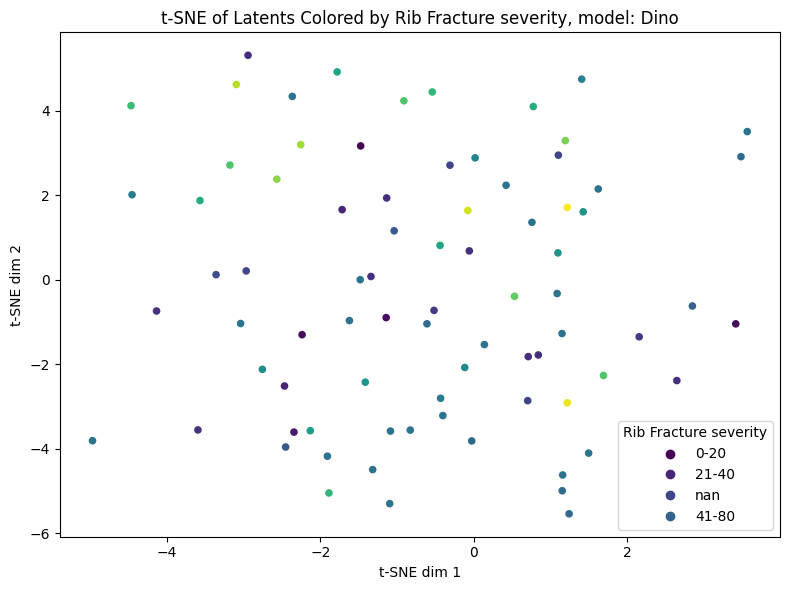

In [71]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=pd.factorize(labels)[0], s=20)
if folder == "06_10_CT_CLIP":
    model = "CT-CLIP (base)"
else:
    model = folder
plt.title(f"t-SNE of Latents Colored by Rib Fracture severity, model: {model}")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")

handles, _ = scatter.legend_elements()
unique_labels = severity_score["severity_group"].unique()
plt.legend(handles, unique_labels, title="Rib Fracture severity")

plt.tight_layout()
plt.show()